# Comparación de Controladores Laterales — Town07
**Figura principal de la tesis — Sección 4.3**

Cuatro controladores evaluados en Town07 (ruta no vista durante el tuneo).  
Perfil de velocidad: **v\_18\_25**. Métricas según sección 4.3.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── Estilo IEEE ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 9,
    'axes.titlesize'   : 9,
    'axes.labelsize'   : 9,
    'xtick.labelsize'  : 8,
    'ytick.labelsize'  : 8,
    'legend.fontsize'  : 8,
    'axes.linewidth'   : 0.7,
    'grid.linewidth'   : 0.4,
    'grid.alpha'       : 0.35,
    'lines.linewidth'  : 1.2,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 600,
    'savefig.bbox'     : 'tight',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

# ── Paleta de colores consistente ────────────────────────────────────────────
COLORS = {
    'Stanley'  : '#D62728',   # rojo
    'NMPC-MD'  : '#1F77B4',   # azul IEEE
    'NMPC-DD'  : '#7D3C98',   # purpura
    'NMPC-PINN': '#1D6B2E',   # verde oscuro
    'ref'      : '#AAAAAA',   # gris referencia
}
LABELS = {
    'Stanley'  : 'Stanley',
    'NMPC-MD'  : 'NMPC-MD',
    'NMPC-DD'  : 'NMPC-DD',
    'NMPC-PINN': 'NMPC-PINN',
}

# ── Cargar trayectoria de referencia ─────────────────────────────────────────
traj    = np.load('traj_dataset_Town07.npy', allow_pickle=True).item()
x_ref   = traj['x']
y_ref   = traj['y']
yaw_ref = np.arctan2(np.sin(traj['yaw']), np.cos(traj['yaw']))
s_ref   = traj['s']
path_xy = np.column_stack([x_ref, y_ref])
N_PATH  = len(x_ref)

# ── Cargar datos de cada controlador ─────────────────────────────────────────
FILES = {
    'Stanley'  : 'data_Town07_stanley_final.npy',
    'NMPC-MD'  : 'data_Town07_mdnmpc_final.npy',
    'NMPC-DD'  : 'data_Town07_ddnmpc_final.npy',
    'NMPC-PINN': 'data_Town07_pinnnmpc_final.npy',
}

ctrl = {}
for name, fname in FILES.items():
    d = np.load(fname, allow_pickle=True).item()
    x_v   = d['x'];  y_v = d['y'];  yaw_v = d['yaw']
    steer = d['steer_rad']

    # Matching waypoint con orientacion compatible
    hint = 0; e_k = []; s_v = []
    for i in range(len(x_v)):
        lo = max(0, hint-10); hi = min(N_PATH-1, hint+300)
        d2 = (path_xy[lo:hi,0]-x_v[i])**2 + (path_xy[lo:hi,1]-y_v[i])**2
        hd = np.abs(np.arctan2(np.sin(yaw_ref[lo:hi]-yaw_v[i]),
                                np.cos(yaw_ref[lo:hi]-yaw_v[i])))
        d2 = d2 + (hd > np.radians(90))*1e9
        idx = lo + int(np.argmin(d2)); hint = idx
        xr, yr_p, psi_r = x_ref[idx], y_ref[idx], yaw_ref[idx]
        e_k.append(float((y_v[i]-yr_p)*np.cos(psi_r) - (x_v[i]-xr)*np.sin(psi_r)))
        s_v.append(float(s_ref[idx]))

    e_k = np.array(e_k); s_v = np.array(s_v)
    ctrl[name] = dict(
        x=x_v, y=y_v, e_k=e_k, s_v=s_v,
        RMSE = float(np.sqrt(np.mean(e_k**2))),
        MAE  = float(np.mean(np.abs(e_k))),
        Emax = float(np.max(np.abs(e_k))),
        TV   = float(np.sum(np.abs(np.diff(steer)))),
    )

# ── Tabla de metricas ─────────────────────────────────────────────────────────
print(f'  {"Controlador":<14} {"RMSE":>8} {"MAE":>8} {"E_max":>8} {"TV_d":>8}')
print('  ' + '-'*52)
for name in LABELS:
    m = ctrl[name]
    print(f'  {name:<14} {m["RMSE"]:>7.4f}m {m["MAE"]:>7.4f}m {m["Emax"]:>7.4f}m {m["TV"]:>7.3f}r')

  Controlador        RMSE      MAE    E_max     TV_d
  ----------------------------------------------------
  Stanley         1.1276m  0.5887m  6.1779m  69.767r
  NMPC-MD         0.5803m  0.2995m  2.8034m  48.342r
  NMPC-DD         0.4155m  0.2439m  2.1918m  58.738r
  NMPC-PINN       0.4486m  0.2756m  1.8705m  47.320r


## Figura 1 — Trayectorias XY (2×2)

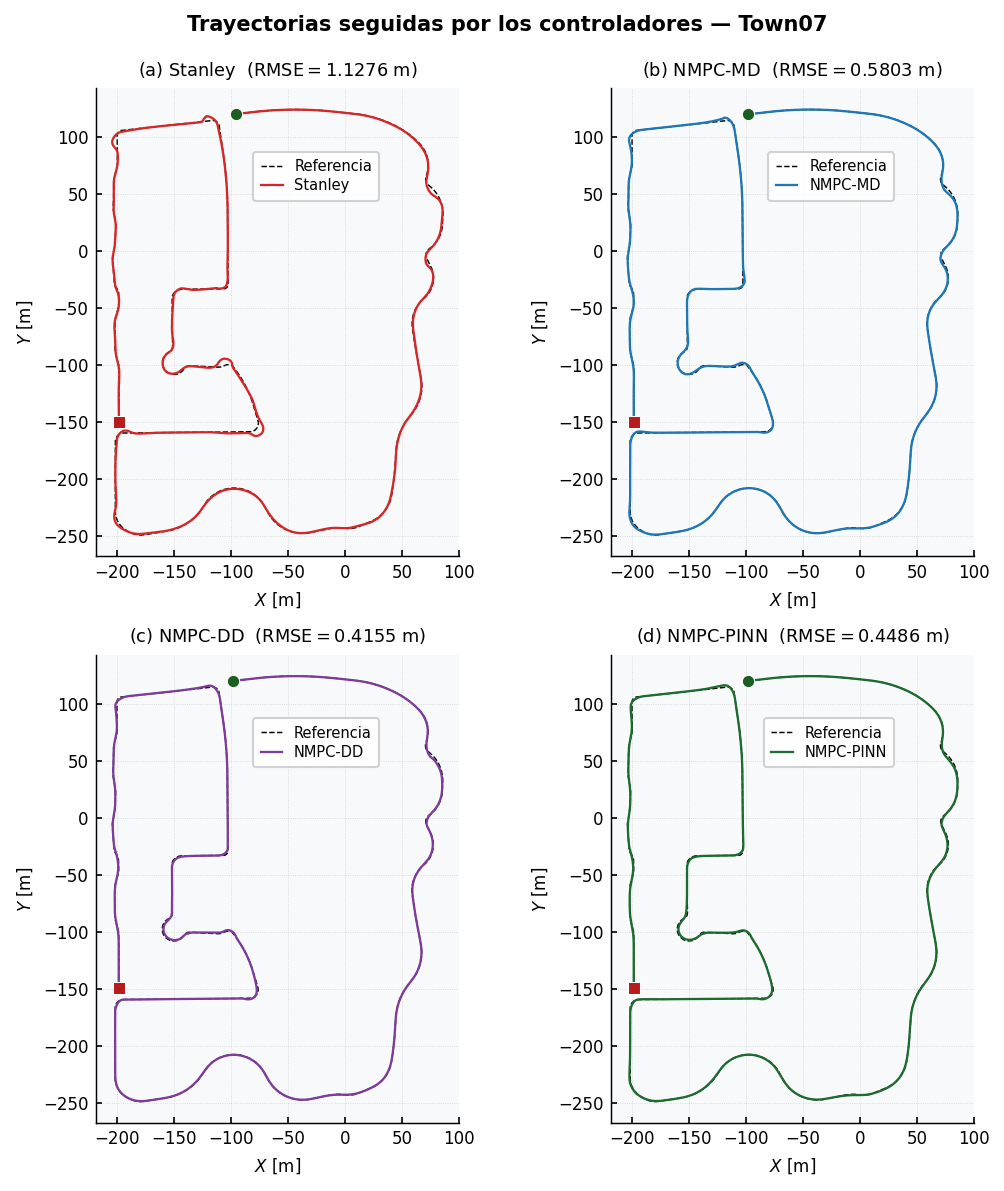

Guardadas: fig_trayectorias_comparacion.pdf / .png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(7.0, 7.8))
fig.suptitle('Trayectorias seguidas por los controladores — Town07',
             fontsize=10, fontweight='bold', y=1.002)

order = ['Stanley', 'NMPC-MD', 'NMPC-DD', 'NMPC-PINN']
panel = ['(a)', '(b)', '(c)', '(d)']

for ax, name, pan in zip(axes.flat, order, panel):
    c  = ctrl[name]
    ax.set_facecolor('#F8F9FA')

    # Referencia
    ax.plot(x_ref, y_ref, color='black', lw=0.7, ls='--',
            alpha=1.00, label='Referencia', zorder=1)

    # Trayectoria del controlador
    ax.plot(c['x'], c['y'], color=COLORS[name], lw=1.1,
            label=LABELS[name], zorder=3)

    # Inicio / Fin
    ax.scatter(c['x'][0],  c['y'][0],  s=35, c='#1B5E20',
               zorder=5, marker='o', edgecolors='white', lw=0.5)
    ax.scatter(c['x'][-1], c['y'][-1], s=35, c='#B71C1C',
               zorder=5, marker='s', edgecolors='white', lw=0.5)

    ax.set_aspect('equal')
    ax.grid(True, ls=':', lw=0.4, alpha=0.5)
    ax.tick_params(direction='in', length=3)
    ax.set_xlabel('$X$ [m]', fontsize=8)
    ax.set_ylabel('$Y$ [m]', fontsize=8)
    ax.set_title(f'{pan} {LABELS[name]}  '
                 f'(RMSE$= ${c["RMSE"]:.4f} m)', fontsize=8.5)
    ax.legend(loc='upper right', bbox_to_anchor=(0.80, 0.88), fontsize=7, handlelength=1.5,
              framealpha=0.88, edgecolor='#CCCCCC',
              borderpad=0.5, labelspacing=0.3)

plt.tight_layout(pad=0.6, h_pad=0.9, w_pad=0.7)
plt.savefig('fig_trayectorias_comparacion.pdf', format='pdf')
plt.savefig('fig_trayectorias_comparacion.png')
plt.show()
print('Guardadas: fig_trayectorias_comparacion.pdf / .png')

## Figura 2 — Error de pista $e_k$ (2×2)

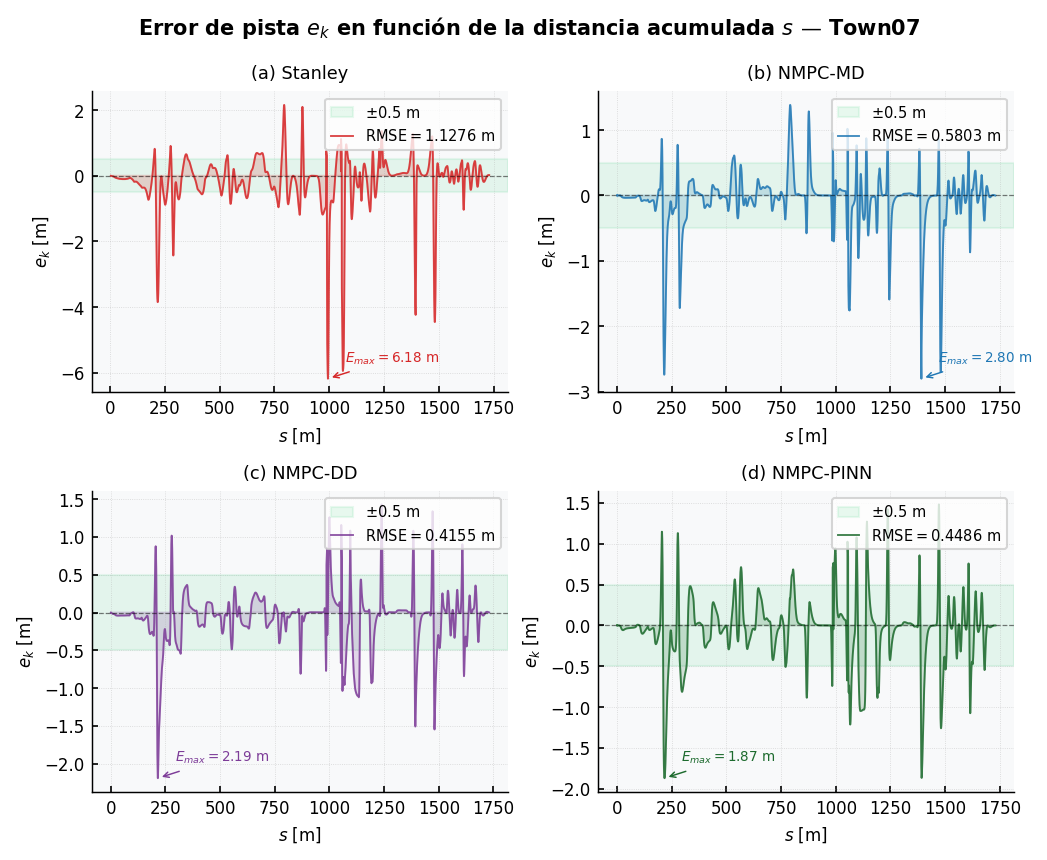

Guardadas: fig_cte_comparacion.pdf / .png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(7.0, 5.6), sharex=False, sharey=False)
fig.suptitle(
    r'Error de pista $e_k$ en función de la distancia acumulada $s$ — Town07',
    fontsize=10, fontweight='bold', y=1.002)

for ax, name, pan in zip(axes.flat, order, panel):
    c = ctrl[name]
    ax.set_facecolor('#F8F9FA')

    # Banda ±0.5 m de referencia
    s_lo, s_hi = c['s_v'].min(), c['s_v'].max()
    ax.axhspan(-0.5, 0.5, color='#2ECC71', alpha=0.10, zorder=0,
               label=r'$\pm$0.5 m')

    # Relleno bajo la curva
    ax.fill_between(c['s_v'], c['e_k'], 0,
                    where=(c['e_k'] >= 0), alpha=0.18,
                    color=COLORS[name], zorder=1)
    ax.fill_between(c['s_v'], c['e_k'], 0,
                    where=(c['e_k'] <  0), alpha=0.18,
                    color=COLORS[name], zorder=1)

    # Curva CTE
    ax.plot(c['s_v'], c['e_k'], color=COLORS[name], lw=0.9,
            alpha=0.85, zorder=2,
            label=f'RMSE$= ${c["RMSE"]:.4f} m')

    ax.axhline(0, color='k', lw=0.6, ls='--', alpha=0.5, zorder=3)

    ax.set_xlabel(r'$s$ [m]', fontsize=8)
    ax.set_ylabel(r'$e_k$ [m]', fontsize=8)
    ax.set_title(f'{pan} {LABELS[name]}', fontsize=8.5)
    ax.tick_params(direction='in', length=3)
    ax.grid(True, ls=':', lw=0.4, alpha=0.5)
    ax.legend(loc='upper right', fontsize=7, handlelength=1.5,
              framealpha=0.8, edgecolor='#CCCCCC')

    # Anotacion Emax
    idx_max = np.argmax(np.abs(c['e_k']))
    ax.annotate(f'$E_{{max}}$$= ${c["Emax"]:.2f} m',
                xy=(c['s_v'][idx_max], c['e_k'][idx_max]),
                xytext=(8, 8), textcoords='offset points',
                fontsize=6.5, color=COLORS[name],
                arrowprops=dict(arrowstyle='->', lw=0.7,
                                color=COLORS[name]))

plt.tight_layout(pad=0.6, h_pad=1.0, w_pad=0.7)
plt.savefig('fig_cte_comparacion.pdf', format='pdf')
plt.savefig('fig_cte_comparacion.png')
plt.show()
print('Guardadas: fig_cte_comparacion.pdf / .png')

## Figura 3 — Comparación de métricas (barras)

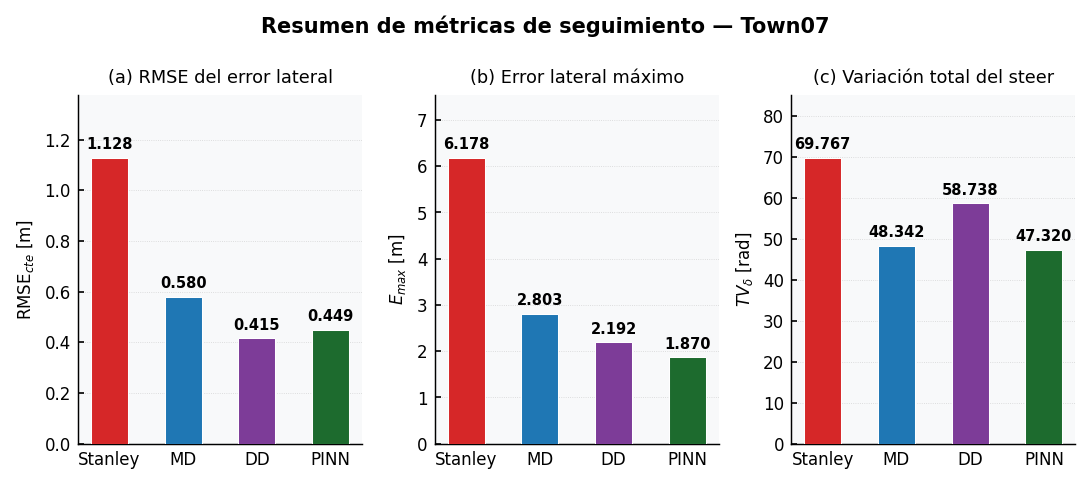

Guardadas: fig_metricas_barras.pdf / .png


In [5]:
names  = list(LABELS.keys())
colors = [COLORS[n] for n in names]

rmse_v = [ctrl[n]['RMSE'] for n in names]
mae_v  = [ctrl[n]['MAE']  for n in names]
emax_v = [ctrl[n]['Emax'] for n in names]
tv_v   = [ctrl[n]['TV']   for n in names]

fig, axes = plt.subplots(1, 3, figsize=(7.2, 3.0))
fig.suptitle('Resumen de métricas de seguimiento — Town07',
             fontsize=10, fontweight='bold', y=1.03)

short = ['Stanley', 'MD', 'DD', 'PINN']

def bar_panel(ax, vals, ylabel, title, panel_label):
    bars = ax.bar(short, vals, color=colors, width=0.5,
                  edgecolor='white', linewidth=0.5, zorder=3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.02,
                f'{v:.3f}', ha='center', va='bottom',
                fontsize=7, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_title(f'{panel_label} {title}', fontsize=8.5)
    ax.set_ylim(0, max(vals) * 1.22)
    ax.tick_params(direction='in', length=3)
    ax.grid(axis='y', ls=':', lw=0.4, alpha=0.5, zorder=0)
    ax.set_facecolor('#F8F9FA')

bar_panel(axes[0], rmse_v, 'RMSE$_{cte}$ [m]', 'RMSE del error lateral', '(a)')
bar_panel(axes[1], emax_v, '$E_{max}$ [m]',    'Error lateral máximo',   '(b)')
bar_panel(axes[2], tv_v,   '$TV_{\\delta}$ [rad]', 'Variación total del steer', '(c)')

plt.tight_layout(pad=0.5, w_pad=0.8)
plt.savefig('fig_metricas_barras.pdf', format='pdf')
plt.savefig('fig_metricas_barras.png')
plt.show()
print('Guardadas: fig_metricas_barras.pdf / .png')

## Figura 4 — CTE superpuesto (todos en una sola figura)

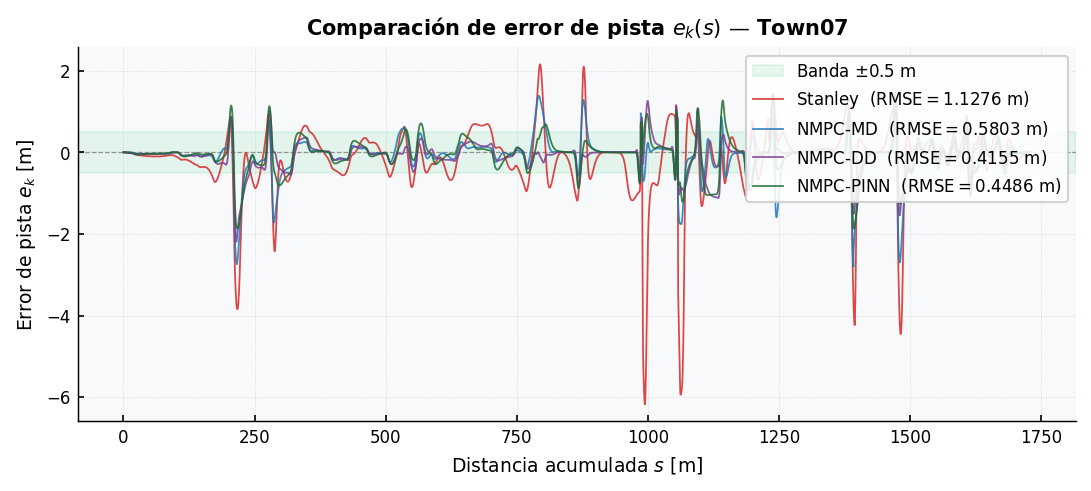

Guardada: fig_cte_superpuesto.pdf / .png


In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.2))
ax.set_facecolor('#F8F9FA')

ax.axhspan(-0.5, 0.5, color='#2ECC71', alpha=0.10, zorder=0,
           label=r'Banda $\pm$0.5 m')
ax.axhline(0, color='k', lw=0.6, ls='--', alpha=0.4, zorder=1)

for name in order:
    c = ctrl[name]
    ax.plot(c['s_v'], c['e_k'], color=COLORS[name], lw=0.85, alpha=0.85,
            label=f'{LABELS[name]}  (RMSE$= ${c["RMSE"]:.4f} m)', zorder=2)

ax.set_xlabel(r'Distancia acumulada $s$ [m]', fontsize=9)
ax.set_ylabel(r'Error de pista $e_k$ [m]', fontsize=9)
ax.set_title(r'Comparación de error de pista $e_k(s)$ — Town07',
             fontsize=10, fontweight='bold')
ax.tick_params(direction='in', length=3)
ax.grid(True, ls=':', lw=0.4, alpha=0.5)
ax.legend(fontsize=8, loc='upper right', framealpha=0.88,
          edgecolor='#CCCCCC', handlelength=1.8)

plt.tight_layout(pad=0.5)
plt.savefig('fig_cte_superpuesto.pdf', format='pdf')
plt.savefig('fig_cte_superpuesto.png')
plt.show()
print('Guardada: fig_cte_superpuesto.pdf / .png')

## Tabla LaTeX para la tesis

In [7]:
print('% Tabla comparativa de controladores laterales -- Town07')
print(r'\begin{table}[htbp]')
print(r'\centering')
print(r'\caption{Métricas de seguimiento de trayectoria en Town07 (ruta no vista).}')
print(r'\label{tab:comparacion_town07}')
print(r'\begin{tabular}{lcccc}')
print(r'\hline')
print(r'Controlador & RMSE$_{cte}$ [m] & MAE$_{cte}$ [m] & $E_{max}$ [m] & $TV_{\delta}$ [rad] \\')
print(r'\hline')
for name in order:
    m = ctrl[name]
    best_rmse = name == min(order, key=lambda n: ctrl[n]['RMSE'])
    val = f'{m["RMSE"]:.4f}'
    if best_rmse: val = r'\textbf{' + val + '}'
    print(f'{LABELS[name]} & {val} & {m["MAE"]:.4f} & {m["Emax"]:.4f} & {m["TV"]:.4f} \\\\')
print(r'\hline')
print(r'\end{tabular}')
print(r'\end{table}')

% Tabla comparativa de controladores laterales -- Town07
\begin{table}[htbp]
\centering
\caption{Métricas de seguimiento de trayectoria en Town07 (ruta no vista).}
\label{tab:comparacion_town07}
\begin{tabular}{lcccc}
\hline
Controlador & RMSE$_{cte}$ [m] & MAE$_{cte}$ [m] & $E_{max}$ [m] & $TV_{\delta}$ [rad] \\
\hline
Stanley & 1.1276 & 0.5887 & 6.1779 & 69.7674 \\
NMPC-MD & 0.5803 & 0.2995 & 2.8034 & 48.3417 \\
NMPC-DD & \textbf{0.4155} & 0.2439 & 2.1918 & 58.7384 \\
NMPC-PINN & 0.4486 & 0.2756 & 1.8705 & 47.3195 \\
\hline
\end{tabular}
\end{table}
